# EDA Изучаю dataset.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

df = pd.read_csv("used_cars.csv")

In [165]:
df.shape

(4009, 12)

In [166]:
for clmn in df.columns.tolist():
    print(clmn)

brand
model
model_year
milage
fuel_type
engine
transmission
ext_col
int_col
accident
clean_title
price


In [167]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   brand         4009 non-null   str  
 1   model         4009 non-null   str  
 2   model_year    4009 non-null   int64
 3   milage        4009 non-null   str  
 4   fuel_type     3839 non-null   str  
 5   engine        4009 non-null   str  
 6   transmission  4009 non-null   str  
 7   ext_col       4009 non-null   str  
 8   int_col       4009 non-null   str  
 9   accident      3896 non-null   str  
 10  clean_title   3413 non-null   str  
 11  price         4009 non-null   str  
dtypes: int64(1), str(11)
memory usage: 376.0 KB


In [168]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [169]:
df.isnull().sum()

brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

In [170]:
for clmn in df.columns.tolist():
    print(f"{clmn}: {df[clmn].nunique()}")

brand: 57
model: 1898
model_year: 34
milage: 2818
fuel_type: 7
engine: 1146
transmission: 62
ext_col: 319
int_col: 156
accident: 2
clean_title: 1
price: 1569


In [171]:
df[df['fuel_type'].isnull()]['engine'].unique()

<StringArray>
[      '534.0HP Electric Motor Electric Fuel System',
       '536.0HP Electric Motor Electric Fuel System',
       '835.0HP Electric Motor Electric Fuel System',
       '620.0HP Electric Motor Electric Fuel System',
       '455.0HP Electric Motor Electric Fuel System',
       '670.0HP Electric Motor Electric Fuel System',
                                          'Electric',
       '355.0HP Electric Motor Electric Fuel System',
       '329.0HP Electric Motor Electric Fuel System',
       '271.0HP Electric Motor Electric Fuel System',
                            'Standard Range Battery',
               '111.2Ah / FR 70kW / RR 160kW (697V)',
       '200.0HP Electric Motor Electric Fuel System',
       '425.0HP Electric Motor Electric Fuel System',
       '147.0HP Electric Motor Electric Fuel System',
       '107.0HP Electric Motor Electric Fuel System',
                             'Dual Motor - Standard',
  '403.0HP 2.0L Electric Motor Electric Fuel System',
       '290.0H

# Выводы на данный момент:
1) Пропуск в типе топлива, это электричество, т.к. все машины с таким пропуском имеют электрический двигатель, следовательно дополню пропуск как электричество.
2) Пропуск в инцидентах и в ПТС, заменю на "No info" и "No", т.к. в целом эти пропуски такую информацию и несут логически, следовательно это не отсуствие информации и такое лучше заполнить.
3) Цена(таргет в данном датасете) и пробег, в таблице указаны не float или int, а str, так что заменю на корректный тип данных, чтобы с ними можно было работать как с числами. + Поменяю цену на рубли по курсу на момент создания данного ноутбука и мили заменю на километры, просто для удобства восприятия. На обучение такое изменение повлиять не должно, ровно как нормировка если приводить аналогию.
4) Подглядел в работах из кагла, что из фичи двигателя можно вычлянить его мощность и получается добавиться еще одна фича(также можно с объемом двигателя и количесвтом цилиндров), но пока не ясно что там с пропусками и полезен ли вообще данный признак.
5) Учитывая количество категорий в цветах интерьера и экстерьера, число моделей, двигателей, предполагаю, что можно убрать эти данные из датасета, тем более мне нужно ббудет сделать OneHotEncoding, а для такого числа категорий это не эффективно.

# EDA Заполнение пропусков, работа с признаками и тд

In [ ]:
df_clean = df.copy()

In [173]:
df_clean['fuel_type'] = df_clean['fuel_type'].fillna('Electric')
df_clean['clean_title'] = df_clean['clean_title'].fillna('No')
df_clean['accident'] = df_clean['accident'].fillna('No info')

In [174]:
usd_to_rub = 78.03
mi_to_km = 1.60934

df_clean['price'] = pd.to_numeric(
    df_clean['price'].str.replace(r'[^\d.]', '', regex=True),
    errors='coerce'
)

df_clean['price'] = df_clean['price'] * usd_to_rub

df_clean['milage'] = pd.to_numeric(
    df_clean['milage'].str.replace(r'[^\d.]', '', regex=True),
    errors='coerce'
)

df_clean['milage'] = df_clean['milage'] * mi_to_km

In [175]:
horsepower_test = pd.to_numeric(
    df_clean['engine']
        .astype(str)
        .str.extract(r'(\d+(?:\.\d+)?)\s*HP', expand=False),
    errors='coerce'
)

engine_volume_test = pd.to_numeric(
    df_clean['engine']
        .astype(str)
        .str.extract(r'(\d+(?:\.\d+)?)\s*(?:L|Liter)', expand=False),
    errors='coerce'
)

cylinders_test = pd.to_numeric(
    df_clean['engine']
        .astype(str)
        .str.extract(r'(?:V|I)(\d+)', expand=False),
    errors='coerce'
)

features_test = {
    'horsepower': horsepower_test,
    'engine_volume': engine_volume_test,
    'cylinders': cylinders_test
}

for name, values in features_test.items():
    coverage = values.notna().mean() * 100
    missing = values.isna().sum()

    print(
        f'{name}: покрытие {coverage:.2f}%, '
        f'пропусков {missing}'
    )

horsepower: покрытие 79.85%, пропусков 808
engine_volume: покрытие 94.59%, пропусков 217
cylinders: покрытие 34.72%, пропусков 2617


In [176]:
df_clean['horsepower'] = horsepower_test
df_clean['engine_volume'] = engine_volume_test

In [177]:
df_clean.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,horsepower,engine_volume
0,Ford,Utility Police Interceptor Base,2013,82076.34000,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,803709.00,300.0,3.7
1,Hyundai,Palisade SEL,2021,55911.69028,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,2965530.15,NaN,3.8
2,Lexus,RX 350 RX 350,2022,36004.15448,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,No,4260281.94,NaN,3.5
3,INFINITI,Q50 Hybrid Sport,2015,143070.32600,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,1209465.00,354.0,3.5
4,Audi,Q3 45 S line Premium Plus,2021,15827.85890,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,No,2730971.97,NaN,2.0


Добавил в область признаков объем двигателя и HP, т.к они есть у большинства машин, а вот количество цилиндров указано даже не в половине, так что их пропущу.

# EDA Графики

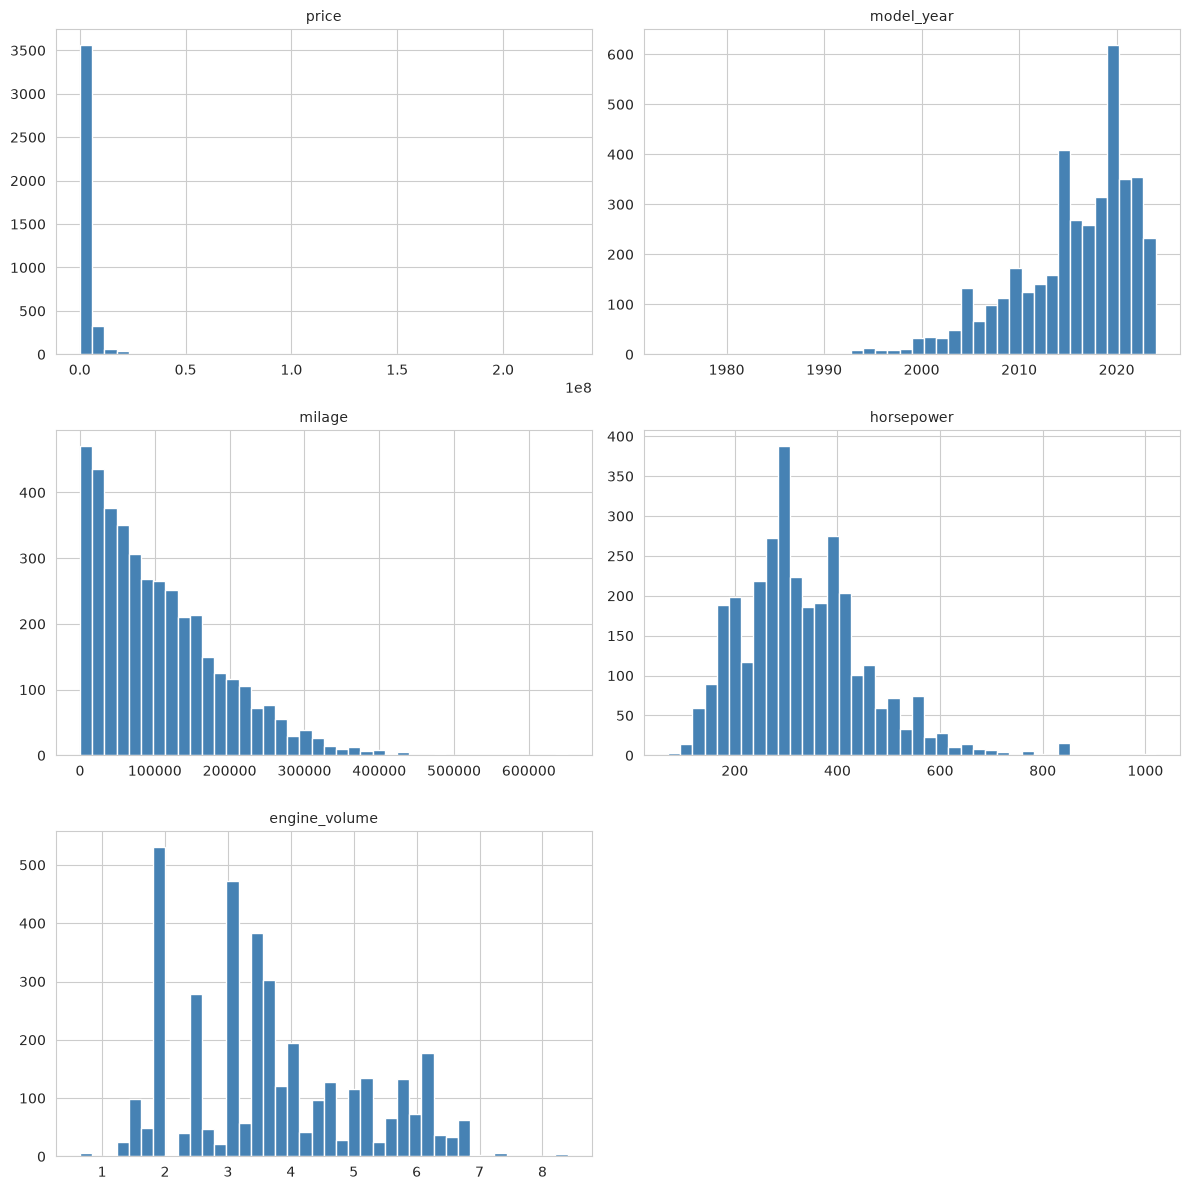

In [178]:
numeric_cols = ['price', 'model_year', 'milage', 'horsepower', 'engine_volume']

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df_clean[col].hist(
        bins=40,
        ax=axes[i],
        color='steelblue',
        edgecolor='white'
    )
    axes[i].set_title(col, fontsize=10)

axes[-1].axis('off')

plt.tight_layout()
plt.show()

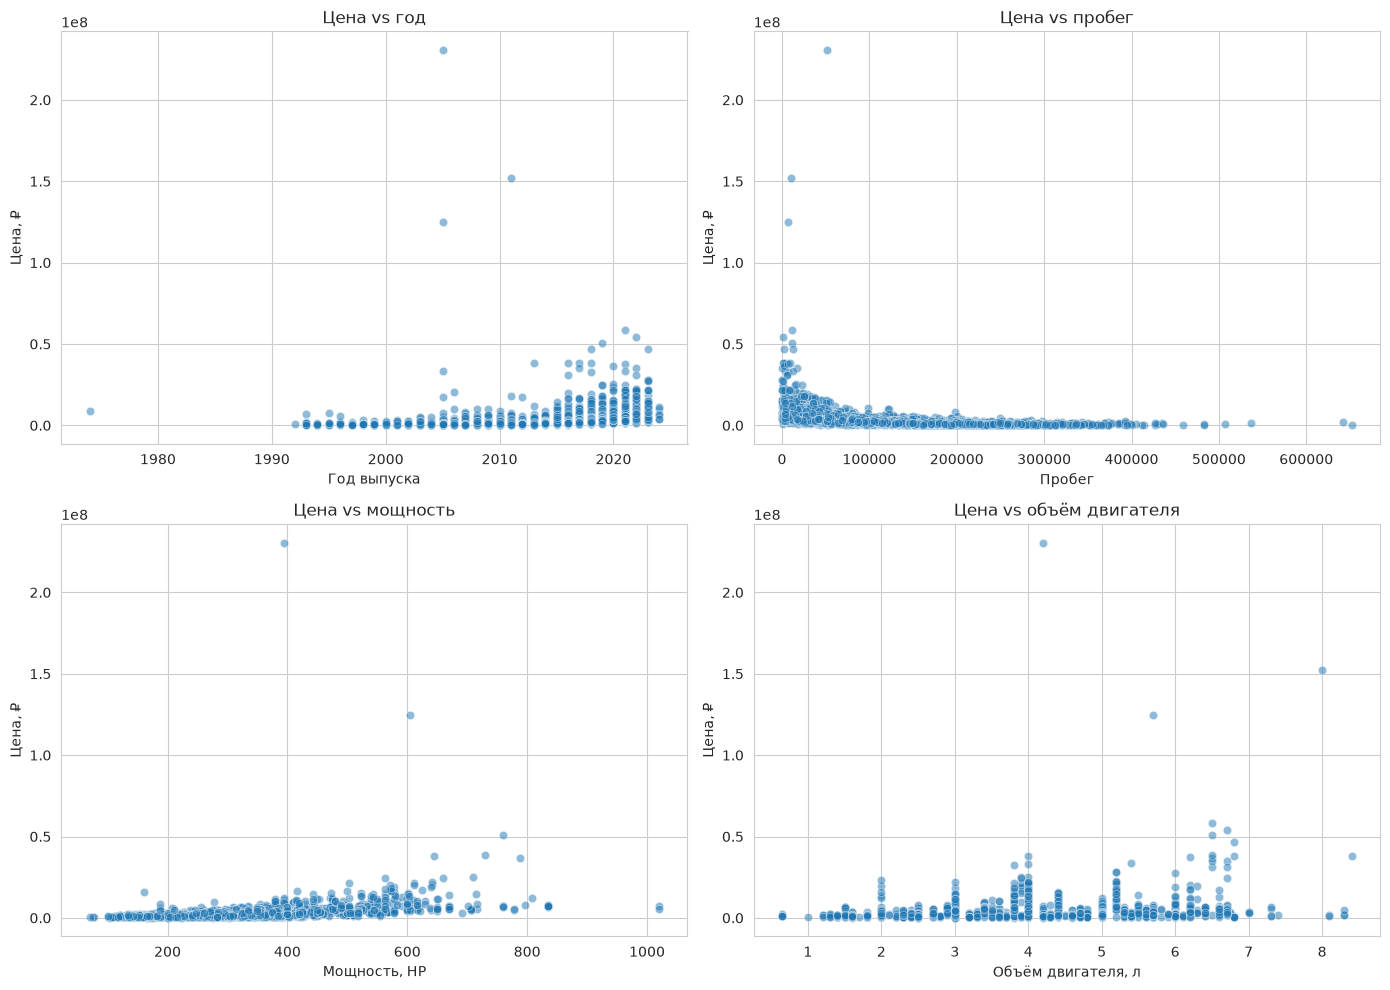

In [179]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.scatterplot(data=df_clean, x='model_year', y='price', ax=axes[0, 0], alpha=0.5)
axes[0, 0].set_title('Цена vs год')
axes[0, 0].set_xlabel('Год выпуска')
axes[0, 0].set_ylabel('Цена, ₽')

sns.scatterplot(data=df_clean, x='milage', y='price', ax=axes[0, 1], alpha=0.5)
axes[0, 1].set_title('Цена vs пробег')
axes[0, 1].set_xlabel('Пробег')
axes[0, 1].set_ylabel('Цена, ₽')

sns.scatterplot(data=df_clean, x='horsepower', y='price', ax=axes[1, 0], alpha=0.5)
axes[1, 0].set_title('Цена vs мощность')
axes[1, 0].set_xlabel('Мощность, HP')
axes[1, 0].set_ylabel('Цена, ₽')

sns.scatterplot(data=df_clean, x='engine_volume', y='price', ax=axes[1, 1], alpha=0.5)
axes[1, 1].set_title('Цена vs объём двигателя')
axes[1, 1].set_xlabel('Объём двигателя, л')
axes[1, 1].set_ylabel('Цена, ₽')

plt.tight_layout()
plt.show()

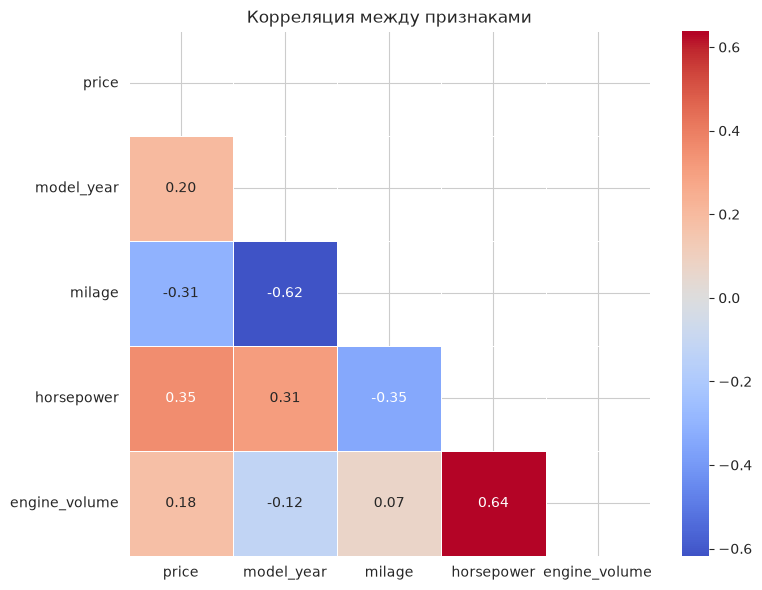

In [180]:
plt.figure(figsize=(8, 6))
numeric_cols = ['price', 'model_year', 'milage', 'horsepower', 'engine_volume']
corr = df_clean[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Корреляция между признаками')
plt.tight_layout()
plt.show()


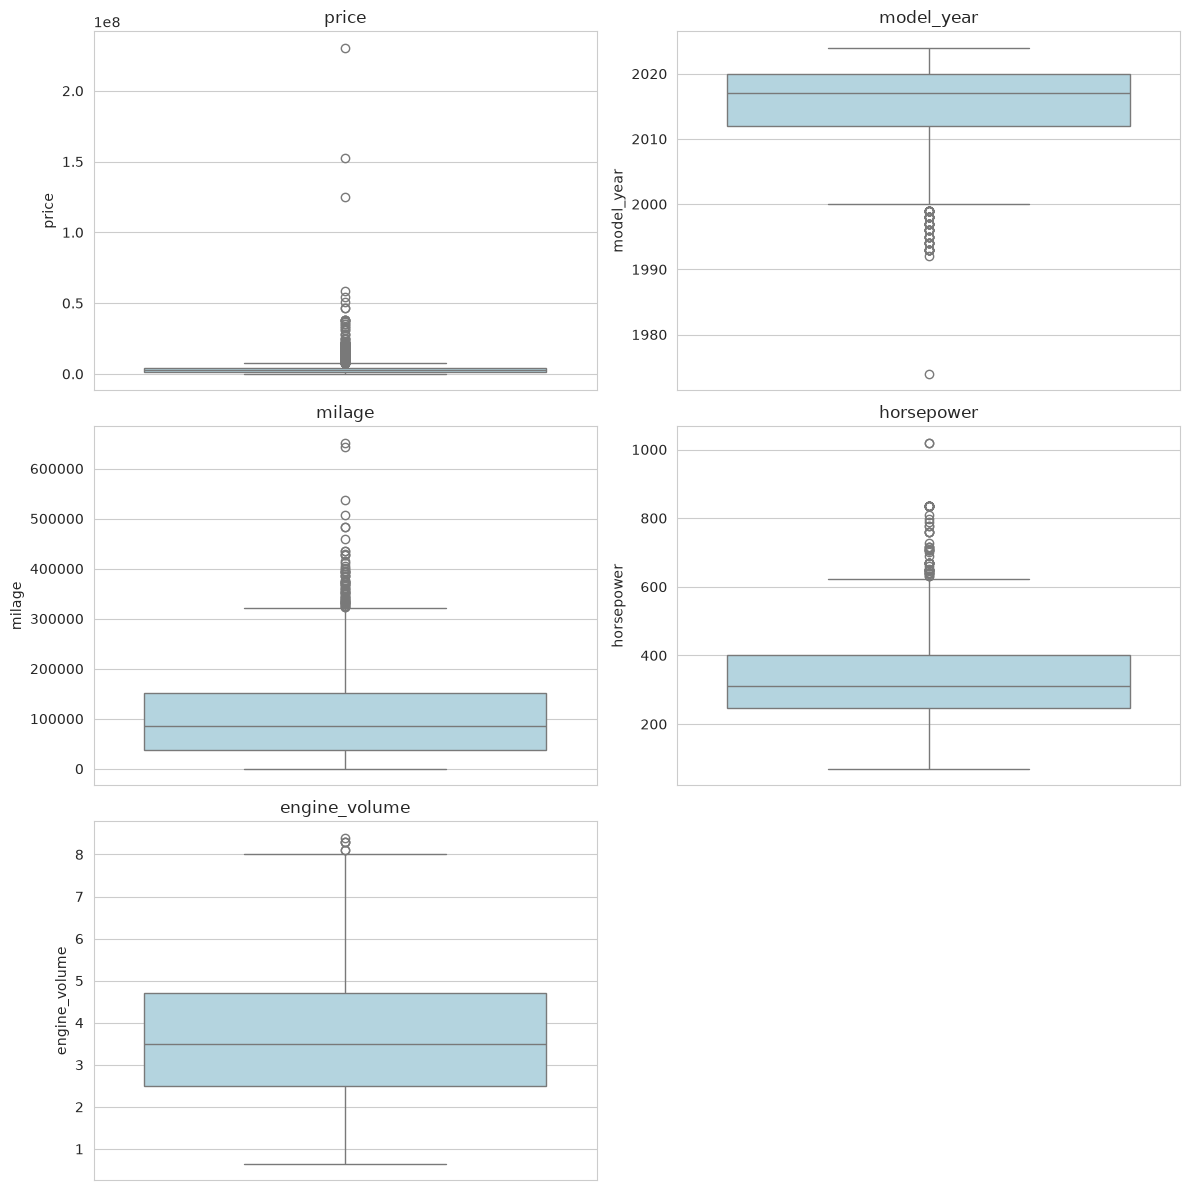

In [181]:
numeric_cols = ['price', 'model_year', 'milage', 'horsepower', 'engine_volume']

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(
        y=df_clean[col],
        ax=axes[i],
        color='lightblue'
    )
    axes[i].set_title(col)

# Убираем пустой шестой график
axes[-1].axis('off')

plt.tight_layout()
plt.show()

In [182]:
cat_cols = [
    'brand',
    'fuel_type',
    'transmission',
    'accident',
    'clean_title'
]

for col in cat_cols:
    print(f'\n{col}')

    display(
        df_clean.groupby(col)['price']
        .agg(['count', 'mean', 'median'])
        .sort_values('median', ascending=False)
    )


brand


,count,mean,median
brand,,,
Bugatti,1,1.522361e+08,1.522361e+08
Rolls-Royce,11,2.894856e+07,3.120810e+07
Lamborghini,26,2.272498e+07,2.013174e+07
Ferrari,12,1.902299e+07,1.946068e+07
McLaren,6,1.665609e+07,1.423657e+07
Bentley,33,1.073330e+07,8.894640e+06
Lucid,3,7.956433e+06,7.724970e+06
Rivian,17,7.267572e+06,7.295805e+06
Aston,9,8.989021e+06,6.242400e+06



fuel_type


,count,mean,median
fuel_type,,,
Electric,170,4.245860e+06,3667331.97
Hybrid,194,4.012786e+06,3550286.97
Diesel,116,3.799704e+06,3546463.50
Plug-In Hybrid,34,3.585180e+06,3507058.35
Gasoline,3309,3.475341e+06,2336998.50
E85 Flex Fuel,139,1.774723e+06,1521585.00
–,45,2.789252e+06,1193859.00
not supported,2,1.092420e+06,1092420.00



transmission


,count,mean,median
transmission,,,
7-Speed,1,5.851860e+07,58518598.50
8-SPEED A/T,1,2.262800e+07,22627997.73
"Automatic, 8-Spd Dual-Clutch",1,1.864137e+07,18641367.00
Manual,2,1.722497e+07,17224966.44
7-Speed DCT Automatic,1,1.677645e+07,16776450.00
...,...,...,...
"Auto, 6-Spd w/CmdShft",1,1.240677e+06,1240677.00
6-Speed Automatic with Auto-Shift,5,3.191162e+06,1217189.97
5-Speed A/T,86,1.373836e+06,1170450.00



accident


,count,mean,median
accident,,,
No info,113,3.963018e+06,2848095.000
None reported,2910,3.873259e+06,2783135.025
At least 1 accident or damage reported,986,2.249722e+06,1630827.000



clean_title


,count,mean,median
clean_title,,,
No,596,4.736037e+06,3355016.895
Yes,3413,3.256534e+06,2262870.000


In [183]:
df_clean = df_clean.drop(
    columns=['engine', 'ext_col', 'int_col', 'model']
)

# Выводы после графиков
1) По корреляции можно предположить, что один из признаков год выпуска или пробег можно будет убрать, но стоит проверить, т.к. корреляция не прям равна 1, а лишь 0.62.
2) Также судя по корреляции HP должен быть самым полезным признаком для предсказания цены.
3) Цена имеет сильные выбросы на нескольих экземплярах, нужно будет проверить обучение с ними и без них. ВЫбросы сами по себе реальны, это просто дорогие экземпляры машин, в рамках разумного. Но вот вопрос будет ли положительное влияние на обучение, скорее всего нет.
4) Не совсем понятно, нужно ли что то делать с выбросами в признаках. Трогать их не буду, но не понимаю нужно ли как то с ними отдельно работать и нужно ли как то обрабатывать еденичные экземпляры категорий.

# Создаем, обучаем и проверяем разные модели на 80% данных

In [184]:
from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error

numeric_cols = ['model_year', 'milage', 'horsepower', 'engine_volume']
categorical_cols = ['brand', 'fuel_type', 'transmission', 'accident', 'clean_title']

X = df_clean.drop(columns='price')
y = df_clean['price']

X_dev, X_test, y_dev, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

df_dev = X_dev.copy()
df_dev['price'] = y_dev

price_limit = df_dev['price'].quantile(0.99)

df_dev_no_outliers = df_dev[
    df_dev['price'] <= price_limit
].copy()

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

linear_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

datasets = {
    'С выбросами': df_dev,
    'Без выбросов': df_dev_no_outliers
}

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for name, data in datasets.items():
    X_current = data.drop(columns='price')
    y_current = data['price']

    scores = cross_validate(
        linear_pipeline,
        X_current,
        y_current,
        cv=cv,
        scoring={
            'r2': 'r2',
            'mae': 'neg_mean_absolute_error',
            'rmse': 'neg_root_mean_squared_error'
        }
    )

    print(f'\n{name}')
    print('CV R²:', scores['test_r2'].mean())
    print('CV R² std:', scores['test_r2'].std())
    print('CV MAE:', -scores['test_mae'].mean())
    print('CV RMSE:', -scores['test_rmse'].mean())


С выбросами
CV R²: 0.5937074411930198
CV R² std: 0.0729385353834787
CV MAE: 1197645.026781976
CV RMSE: 2454419.7648314494

Без выбросов
CV R²: 0.6510906306244875
CV R² std: 0.023325093618272716
CV MAE: 951186.1746902326
CV RMSE: 1576015.8281507888


Все метрики улучшились при отбрасывании выбросов, следовательно в дальнейшем я буду использовать данные для обучения без них. MAPE не стал использовать т.к. на сколько я помню он спецефически чувствителен к выбросам, то есть абс разница не так сильно штрафуется, но сильно штрафуется порядковая разница, то есть 1/2 штрафанется сильнее чем 1500/2000, хотя абс разница 1 против 500.

In [185]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import RandomizedSearchCV, cross_validate, KFold
from scipy.stats import loguniform

X_dev = df_dev_no_outliers.drop(columns='price')
y_dev = df_dev_no_outliers['price']

lasso_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso(max_iter=20000))
])

param_distributions = {
    'model__alpha': loguniform(1e1, 1e7)
}

inner_cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=1
)

lasso_search = RandomizedSearchCV(
    lasso_pipeline,
    param_distributions=param_distributions,
    n_iter=30,
    cv=inner_cv,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

scores = cross_validate(
    lasso_search,
    X_dev,
    y_dev,
    cv=cv,
    scoring={
        'r2': 'r2',
        'mae': 'neg_mean_absolute_error',
        'rmse': 'neg_root_mean_squared_error'
    },
    n_jobs=-1
)

print('Lasso')
print('CV R²:', scores['test_r2'].mean())
print('CV R² std:', scores['test_r2'].std())
print('CV MAE:', -scores['test_mae'].mean())
print('CV RMSE:', -scores['test_rmse'].mean())

Lasso
CV R²: 0.6491899901427546
CV R² std: 0.03380235885621691
CV MAE: 951642.7800351322
CV RMSE: 1579976.3497911082


L1 регулеризация не улучшила результат, по сравнению с обычной линейной регрессией, так что теперь попробую снова лин регрессию, но с отбором признаков через L1.

In [186]:
from sklearn.feature_selection import SelectFromModel

lasso_ols_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('selector', SelectFromModel(
        Lasso(max_iter=20000)
    )),
    ('model', LinearRegression())
])

param_distributions = {
    'selector__estimator__alpha': loguniform(1e1, 1e5)
}

lasso_ols_search = RandomizedSearchCV(
    lasso_ols_pipeline,
    param_distributions=param_distributions,
    n_iter=30,
    cv=inner_cv,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

scores = cross_validate(
    lasso_ols_search,
    X_dev,
    y_dev,
    cv=cv,
    scoring={
        'r2': 'r2',
        'mae': 'neg_mean_absolute_error',
        'rmse': 'neg_root_mean_squared_error'
    },
    n_jobs=-1
)

print('L1 selection + LinearRegression')
print('CV R²:', scores['test_r2'].mean())
print('CV R² std:', scores['test_r2'].std())
print('CV MAE:', -scores['test_mae'].mean())
print('CV RMSE:', -scores['test_rmse'].mean())

L1 selection + LinearRegression
CV R²: 0.6428243803294504
CV R² std: 0.03447785883428191
CV MAE: 963555.4026742491
CV RMSE: 1594391.5544856295


Теперь понятно, что отбор признаков не улучшил результат, так что дальше буду использовать все признаки. Дальше попробую L2.

In [187]:
from sklearn.linear_model import Ridge

ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

param_distributions = {
    'model__alpha': loguniform(1e-3, 1e5)
}

ridge_search = RandomizedSearchCV(
    ridge_pipeline,
    param_distributions=param_distributions,
    n_iter=30,
    cv=inner_cv,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

scores = cross_validate(
    ridge_search,
    X_dev,
    y_dev,
    cv=cv,
    scoring={
        'r2': 'r2',
        'mae': 'neg_mean_absolute_error',
        'rmse': 'neg_root_mean_squared_error'
    },
    n_jobs=-1
)

print('Ridge (L2)')
print('CV R²:', scores['test_r2'].mean())
print('CV R² std:', scores['test_r2'].std())
print('CV MAE:', -scores['test_mae'].mean())
print('CV RMSE:', -scores['test_rmse'].mean())

Ridge (L2)
CV R²: 0.656169784027911
CV R² std: 0.03169311971478105
CV MAE: 951573.4556641697
CV RMSE: 1564159.0581525646


Результат стал немного получше чем у обычной лин регресси, так что пока лучшая модель из всех. Дальше попробую град спуск.

In [188]:
from sklearn.linear_model import SGDRegressor

sgd_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SGDRegressor(
        max_iter=5000,
        tol=1e-3,
        random_state=42
    ))
])

param_distributions = {
    'model__eta0': loguniform(1e-3, 1e1),
    'model__alpha': loguniform(1e-7, 1e-2)
}

sgd_search = RandomizedSearchCV(
    sgd_pipeline,
    param_distributions=param_distributions,
    n_iter=30,
    cv=inner_cv,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

scores = cross_validate(
    sgd_search,
    X_dev,
    y_dev,
    cv=cv,
    scoring={
        'r2': 'r2',
        'mae': 'neg_mean_absolute_error',
        'rmse': 'neg_root_mean_squared_error'
    },
    n_jobs=-1
)

print('SGDRegressor')
print('CV R²:', scores['test_r2'].mean())
print('CV R² std:', scores['test_r2'].std())
print('CV MAE:', -scores['test_mae'].mean())
print('CV RMSE:', -scores['test_rmse'].mean())

/home/darwin/Рабочий стол/ml_projects/first_project/env/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/darwin/Рабочий стол/ml_projects/first_project/env/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/darwin/Рабочий стол/ml_projects/first_project/env/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:1620: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/darwin/Рабочий стол/ml_projects/

SGDRegressor
CV R²: 0.6526164380475316
CV R² std: 0.03652636103372334
CV MAE: 955801.8436028
CV RMSE: 1571896.6666571975


По итогу лучшая модель по метрикам это l2 регулеризация, хотя отличие между всеми моделями не скзаать что огромное. Каждая модель примерно одинаково лучше среднего предсказания(R2), около 0.65, и разброс тоже не сильно отличается, около 0.035. 
Думаю с учетом того, что данные показывают среднее значение определенной метрики по фолдам, то в итоговом обучении и проверке на тесте, любая модель может показать результат лучше или хуже. 
Но вот сильное отличие было при отбрасывании выбросов, с ними разброс хуже примерно в 3 раза, R2 заметно хуже, да и в целом все метрики проседают. Как мне кажется на таких малеьнких датасетах, выбросы очень сильно влияют на обучение, причем в отрицательную сторону, поэтому их нужно убирать. 
Возможно правильнее на каждом датасете смотреть какой то параметр определяющий соотношение количества выбросов и их отклонение от средних значений и уже на основе этого параметра принимать решение об удалении выбросов и до какого порога их вообще удалять.

# Финальное обучение лучшей модели на 80% датасета и дальнейшая проверка на тесте

In [189]:
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

ridge_search.fit(X_dev, y_dev)
print('Лучший alpha:', ridge_search.best_params_['model__alpha'])
y_pred = ridge_search.predict(X_test)

print('Test R²:', r2_score(y_test, y_pred))
print('Test MAE:', mean_absolute_error(y_test, y_pred))
print('Test RMSE:', root_mean_squared_error(y_test, y_pred))

Лучший alpha: 0.8528933855762817
Test R²: 0.07750672736067432
Test MAE: 1756065.4475128949
Test RMSE: 10714677.392080612


Тотальный провал. Модель не может предсказать достаточно точно выбросы, которые из обучающей выборки я убрал, а в тестовой оставил. Получается ошибка у меня была в том, что при проверке на двух датасетах, с выбросами и без, я их неправильно разделил.

Обучая лин регрессию, нужно было выбросы на валидации оставить, тогда я бы еще там увидел плохой результат, а так получается, что там я обучал модель без выбросов и проверял без выбросов, потому такой хороший результат получился. 

Так что дальше немного изменю свою задачу, я уберу вообще выбросы из датасета и сведу задачу к предсказанию цены авто из, скажем так, нормального ценового сегмента, где не будет еденичных экземпляров стоющих каких то космических денег, т.к. мне кажется если все таки обучать модель по всем данным и проверять на всех, результаты будут так себе. Количество выбросов мало, а их разница со среднем огромна, не думаю, мои модели можно обучить такой логике ценообразования, по такому малому числу примеров выбросов.

Теперь уже окончательно уберу из всего датасета выбросы и уже снова обучу ту же модель и проверю на тесте. Понимаю, что тестом пользоваться можно только раз, но переписывать все это занового не вижу огромного смысла, не думаю, что появятся кординальные изменения. 

Получается итоговая задача сводится к предсказанию цен автомобилей из более реального ценового сегмента, выбросы предполагаю нереальны к предсказанию и не имеют смысла из за их единственности, условно среднему покупателю нет дела до таких машин, и цену на них выставляет конкретный человек, который сам может указать цену скольк угодно большой в зависимости от истории машины и тд

In [190]:
price_limit = df_clean['price'].quantile(0.99)

df_no_outliers = df_clean[
    df_clean['price'] <= price_limit
].copy()

print('Было объектов:', len(df_clean))
print('Стало объектов:', len(df_no_outliers))
print('Граница цены:', price_limit)

Было объектов: 4009
Стало объектов: 3968
Граница цены: 21279817.238400016


In [191]:
X = df_no_outliers.drop(columns='price')
y = df_no_outliers['price']

X_dev, X_test, y_dev, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

param_distributions = {
    'model__alpha': loguniform(1e-3, 1e5)
}

ridge_search = RandomizedSearchCV(
    ridge_pipeline,
    param_distributions=param_distributions,
    n_iter=30,
    cv=inner_cv,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

ridge_search.fit(X_dev, y_dev)

print('Лучший alpha:', ridge_search.best_params_['model__alpha'])

Лучший alpha: 0.8528933855762817


In [193]:
y_pred = ridge_search.predict(X_test)

print('Test R²:', r2_score(y_test, y_pred))
print('Test MAE:', mean_absolute_error(y_test, y_pred))
print('Test RMSE:', root_mean_squared_error(y_test, y_pred))

Test R²: 0.6076583350351678
Test MAE: 1003104.5063008781
Test RMSE: 1676682.1750815494


Теперь результаты получились в целом нормальными, и близкими к тем оценкам, что я получал на этапе сравнения моделей. Дальше посмотрим, какой признак имеет больший вес.

In [194]:
best_model = ridge_search.best_estimator_

feature_names = best_model[
    'preprocessor'
].get_feature_names_out()

coefficients = best_model[
    'model'
].coef_

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
})

coef_df['abs_coefficient'] = coef_df['coefficient'].abs()

coef_df = coef_df.sort_values(
    'abs_coefficient',
    ascending=False
)

print(coef_df.to_string(index=False))

                                                                           feature   coefficient  abs_coefficient
                                                            cat__brand_Lamborghini  9.837803e+06     9.837803e+06
                                                                cat__brand_Ferrari  7.892258e+06     7.892258e+06
                                    cat__transmission_Automatic, 8-Spd Dual-Clutch  7.451063e+06     7.451063e+06
                                                            cat__brand_Rolls-Royce  5.686656e+06     5.686656e+06
                                                                cat__brand_McLaren  4.431798e+06     4.431798e+06
                               cat__transmission_8-Speed Automatic with Auto-Shift  4.223092e+06     4.223092e+06
                                                                cat__brand_Bentley  3.264078e+06     3.264078e+06
                                                               cat__transmission_–  3.23

Вдруг понял, что все мои модели линейны, так что добавлю случайный лес.

In [195]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

param_distributions = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__max_depth': [None, 5, 10, 15, 20],
    'model__min_samples_leaf': [1, 2, 4, 8],
    'model__max_features': ['sqrt', 0.5, 1.0]
}

rf_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_distributions,
    n_iter=30,
    cv=inner_cv,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_dev, y_dev)

print('Лучшие параметры:', rf_search.best_params_)

Лучшие параметры: {'model__n_estimators': 500, 'model__min_samples_leaf': 1, 'model__max_features': 0.5, 'model__max_depth': None}


In [196]:
y_pred_rf = rf_search.predict(X_test)

print('Random Forest')
print('Test R²:', r2_score(y_test, y_pred_rf))
print('Test MAE:', mean_absolute_error(y_test, y_pred_rf))
print('Test RMSE:', root_mean_squared_error(y_test, y_pred_rf))

Random Forest
Test R²: 0.8020995007190899
Test MAE: 617288.6494264995
Test RMSE: 1190808.639651703
